# Week 2 — Shallow ML Baselines
### Robust Electricity Theft Detection Under Data-Poisoning Attacks
**Student:** Surekha Suresh | C00317211 | SETU Carlow  
**Supervisor:** Milu Philip

## 1. Imports

In [2]:
!pip3 install lightgbm

  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl (1.6 MB)

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)

POISON_RATES  = [0.0, 0.10, 0.20, 0.30]
POISON_LABELS = ['0%', '10%', '20%', '30%']
MODEL_COLORS = {
    'Random Forest': '#2196F3',
    'AdaBoost':      '#FF9800',
    'XGBoost':       '#E53935',
    'LightGBM':      '#43A047'
}
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print('imports done')

imports done


BASE_PATH_PROCESSED for processed data
BASE_PATH_DATA  for data.csv file

In [5]:
BASE_PATH_PROCESSED = '/Users/sundar.g/Documents/projects folder/ElectricityTheftDetection/processed_data'
BASE_PATH_DATA = '/Users/sundar.g/Documents/projects folder/ElectricityTheftDetection/data.csv'

## 2. Load Poisoned Labels from Week 1

In [6]:
poisoned_labels = {}
for rate in POISON_RATES:
    fname = f'{BASE_PATH_PROCESSED}/y_train_poison_{int(rate*100)}pct.npy'
    poisoned_labels[rate] = np.load(fname)

print('poisoned label sets loaded')
for rate, y_p in poisoned_labels.items():
    print(f'  {int(rate*100):>2}% — shape: {y_p.shape}  theft: {(y_p==1).sum():,}  normal: {(y_p==0).sum():,}')

poisoned label sets loaded
   0% — shape: (54260,)  theft: 27,130  normal: 27,130
  10% — shape: (54260,)  theft: 27,276  normal: 26,984
  20% — shape: (54260,)  theft: 27,284  normal: 26,976
  30% — shape: (54260,)  theft: 27,286  normal: 26,974


## 3. PCA Feature Extraction

Shallow ML models (RF, SVM, XGBoost) cannot extract temporal patterns from 1034 raw daily readings directly.
PCA reduces the dimensionality while retaining 95% of the variance — giving the models meaningful features to work with.
This is applied to raw imputed (unscaled) data, then scaled separately.

In [7]:
df_raw = pd.read_csv(BASE_PATH_DATA)

LABEL_COL = 'FLAG'
y_all = df_raw[LABEL_COL].values
features_raw = df_raw.select_dtypes(include=['number'])
if LABEL_COL in features_raw.columns:
    features_raw = features_raw.drop(columns=[LABEL_COL])

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(features_raw)

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_imputed)

pca = PCA(n_components=0.95, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print(f'original shape  : {X_scaled.shape}')
print(f'after PCA       : {X_pca.shape}')
print(f'variance kept   : {pca.explained_variance_ratio_.sum()*100:.1f}%')

original shape  : (42372, 1034)
after PCA       : (42372, 42)
variance kept   : 95.0%


## 4. Train/Val/Test Split + SMOTE

In [8]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_pca, y_all, test_size=0.30, stratify=y_all, random_state=SEED)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

smote = SMOTE(random_state=SEED)
X_train, y_train = smote.fit_resample(X_temp, y_temp)

print(f'X_train : {X_train.shape}  theft: {(y_train==1).sum():,}  normal: {(y_train==0).sum():,}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}   theft: {(y_test==1).sum():,}  normal: {(y_test==0).sum():,}')

X_train : (54260, 42)  theft: 27,130  normal: 27,130
X_val   : (14830, 42)
X_test  : (14830, 42)   theft: 1,265  normal: 13,565


## 5. Evaluation Functions

In [9]:
def evaluate_model(model, X_test, y_test, model_name, poison_rate, train_time=0):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        'Model':        model_name,
        'Poison_Rate':  f'{int(poison_rate*100)}%',
        'Poison_Float': poison_rate,
        'DR':           round(recall_score(y_test, y_pred), 4),
        'Precision':    round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':       round(recall_score(y_test, y_pred), 4),
        'F1':           round(f1_score(y_test, y_pred), 4),
        'Accuracy':     round(accuracy_score(y_test, y_pred), 4),
        'AUC':          round(roc_auc_score(y_test, y_proba), 4),
        'FPR':          round(fp / (fp + tn), 4),
        'Train_Time_s': round(train_time, 2),
        'y_proba':      y_proba,
        'y_pred':       y_pred
    }


def compute_delta(results, metric='F1'):
    rows = []
    model_names = list(dict.fromkeys([r['Model'] for r in results]))
    for mname in model_names:
        m_res = [r for r in results if r['Model'] == mname]
        clean = next(r[metric] for r in m_res if r['Poison_Rate'] == '0%')
        for r in m_res:
            rows.append({
                'Model':            mname,
                'Poison_Rate':      r['Poison_Rate'],
                f'Delta_{metric}':  round(clean - r[metric], 4),
                f'Clean_{metric}':  clean,
                f'Score_{metric}':  r[metric]
            })
    return pd.DataFrame(rows)

print('evaluate_model and compute_delta ready')

evaluate_model and compute_delta ready


## 6. Train All Models

Three models × four poison levels = 12 training runs.
Each model is trained on poisoned labels but evaluated on the same clean test set.
Only the training labels change — test set is never modified.

In [16]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import sklearn.base
import time

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=SEED,
        n_jobs=-1
    ),
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=50,
        learning_rate=0.5,
        random_state=SEED
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
        random_state=SEED,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    )
}

MODEL_COLORS = {
    'Random Forest': '#2196F3',
    'AdaBoost':      '#FF9800',
    'XGBoost':       '#E53935',
    'LightGBM':      '#43A047'
}

all_results = []

for model_name, model_template in models.items():
    print(f'\n{model_name}')
    print('-' * 40)
    for rate in POISON_RATES:
        model = sklearn.base.clone(model_template)
        y_poisoned = poisoned_labels[rate]

        t0 = time.time()
        model.fit(X_train, y_poisoned)
        elapsed = time.time() - t0

        result = evaluate_model(model, X_test, y_test, model_name, rate, elapsed)
        all_results.append(result)

        print(f'  {int(rate*100):>2}% poison — '
              f'F1={result["F1"]:.4f}  DR={result["DR"]:.4f}  '
              f'AUC={result["AUC"]:.4f}  FPR={result["FPR"]:.4f}  '
              f'({elapsed:.1f}s)')

print('\nall 16 runs done')


Random Forest
----------------------------------------
   0% poison — F1=0.4562  DR=0.8126  AUC=0.9162  FPR=0.1632  (5.8s)
  10% poison — F1=0.4316  DR=0.8024  AUC=0.9051  FPR=0.1786  (5.3s)
  20% poison — F1=0.4056  DR=0.7834  AUC=0.8852  FPR=0.1939  (5.1s)
  30% poison — F1=0.3655  DR=0.7478  AUC=0.8412  FPR=0.2186  (5.2s)

AdaBoost
----------------------------------------
   0% poison — F1=0.2864  DR=0.6617  AUC=0.7651  FPR=0.2759  (31.3s)
  10% poison — F1=0.2914  DR=0.6822  AUC=0.7740  FPR=0.2798  (30.8s)
  20% poison — F1=0.2823  DR=0.6917  AUC=0.7681  FPR=0.2992  (31.9s)
  30% poison — F1=0.2802  DR=0.6640  AUC=0.7488  FPR=0.2868  (35.4s)

XGBoost
----------------------------------------
   0% poison — F1=0.6296  DR=0.9360  AUC=0.9758  FPR=0.0967  (1.0s)
  10% poison — F1=0.5785  DR=0.9091  AUC=0.9638  FPR=0.1151  (1.1s)
  20% poison — F1=0.4852  DR=0.8617  AUC=0.9278  FPR=0.1576  (1.1s)
  30% poison — F1=0.3926  DR=0.7913  AUC=0.8667  FPR=0.2088  (1.0s)

LightGBM
-------------

## 7. Results Table

In [17]:
cols = ['Model','Poison_Rate','DR','Precision','Recall','F1','Accuracy','AUC','FPR','Train_Time_s']
results_df = pd.DataFrame([{k: v for k, v in r.items() if k in cols} for r in all_results])
results_df = results_df[cols]

print(results_df.to_string(index=False))
results_df.to_csv(f'{BASE_PATH_PROCESSED}/week2_results.csv', index=False)

        Model Poison_Rate     DR  Precision  Recall     F1  Accuracy    AUC    FPR  Train_Time_s
Random Forest          0% 0.8126     0.3171  0.8126 0.4562    0.8347 0.9162 0.1632          5.81
Random Forest         10% 0.8024     0.2952  0.8024 0.4316    0.8198 0.9051 0.1786          5.27
Random Forest         20% 0.7834     0.2737  0.7834 0.4056    0.8042 0.8852 0.1939          5.12
Random Forest         30% 0.7478     0.2419  0.7478 0.3655    0.7786 0.8412 0.2186          5.24
     AdaBoost          0% 0.6617     0.1828  0.6617 0.2864    0.7187 0.7651 0.2759         31.32
     AdaBoost         10% 0.6822     0.1853  0.6822 0.2914    0.7170 0.7740 0.2798         30.81
     AdaBoost         20% 0.6917     0.1773  0.6917 0.2823    0.7000 0.7681 0.2992         31.90
     AdaBoost         30% 0.6640     0.1776  0.6640 0.2802    0.7090 0.7488 0.2868         35.39
      XGBoost          0% 0.9360     0.4744  0.9360 0.6296    0.9061 0.9758 0.0967          0.99
      XGBoost         10% 0.90

## 8. Robustness Degradation (Δ)

In [18]:
delta_df = compute_delta(all_results, metric='F1')
delta_pivot = delta_df.pivot(index='Model', columns='Poison_Rate', values='Delta_F1')
delta_pivot = delta_pivot[['0%','10%','20%','30%']]

print('Delta F1 — lower is more robust')
print(delta_pivot.to_string())

delta_auc = compute_delta(all_results, metric='AUC')
delta_auc_pivot = delta_auc.pivot(index='Model', columns='Poison_Rate', values='Delta_AUC')
delta_auc_pivot = delta_auc_pivot[['0%','10%','20%','30%']]

print('\nDelta AUC')
print(delta_auc_pivot.to_string())

delta_df.to_csv(f'{BASE_PATH_PROCESSED}/week2_delta.csv', index=False)

Delta F1 — lower is more robust
Poison_Rate     0%     10%     20%     30%
Model                                     
AdaBoost       0.0 -0.0050  0.0041  0.0062
LightGBM       0.0  0.0237  0.0618  0.1255
Random Forest  0.0  0.0246  0.0506  0.0907
XGBoost        0.0  0.0511  0.1444  0.2370

Delta AUC
Poison_Rate     0%     10%     20%     30%
Model                                     
AdaBoost       0.0 -0.0089 -0.0030  0.0163
LightGBM       0.0  0.0096  0.0303  0.0786
Random Forest  0.0  0.0111  0.0310  0.0750
XGBoost        0.0  0.0120  0.0480  0.1091


## 9. ROC Curves — Per Model, All Poison Levels

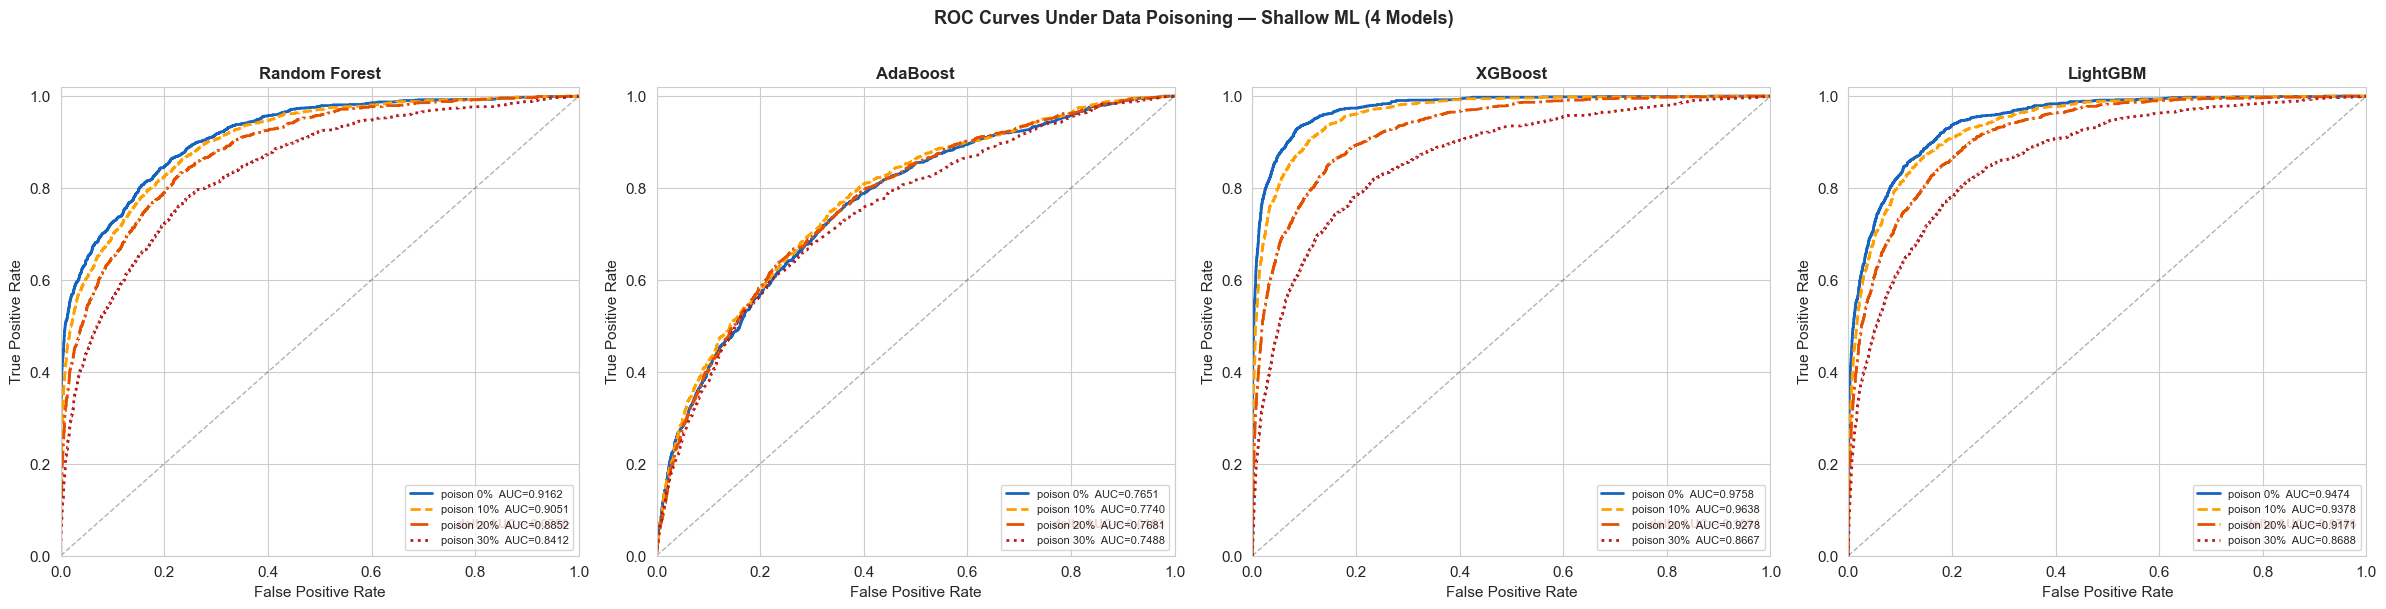

saved: week2_roc_curves.png


In [21]:
# ── Cell 9: ROC Curves — 4 models ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

poison_colors  = {'0%': '#1565C0', '10%': '#FFA000', '20%': '#E65100', '30%': '#B71C1C'}
poison_styles  = {'0%': '-', '10%': '--', '20%': '-.', '30%': ':'}

for ax, model_name in zip(axes, MODEL_COLORS.keys()):
    model_res = [r for r in all_results if r['Model'] == model_name]

    for r in model_res:
        label = r['Poison_Rate']
        fpr_arr, tpr_arr, _ = roc_curve(y_test, r['y_proba'])
        ax.plot(fpr_arr, tpr_arr,
                color=poison_colors[label],
                linestyle=poison_styles[label],
                linewidth=2,
                label=f"poison {label}  AUC={r['AUC']:.4f}")

    ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.3)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

    clean_auc = next(r['AUC'] for r in model_res if r['Poison_Rate'] == '0%')
    worst_auc = next(r['AUC'] for r in model_res if r['Poison_Rate'] == '30%')
    ax.annotate(f'delta AUC = {clean_auc - worst_auc:.4f}',
                xy=(0.98, 0.06), xycoords='axes fraction', ha='right',
                fontsize=9, color='#B71C1C', fontweight='bold')

plt.suptitle('ROC Curves Under Data Poisoning — Shallow ML (4 Models)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/sundar.g/Documents/projects folder/ElectricityTheftDetection/week2/', dpi=150, bbox_inches='tight')
plt.show()
print('saved: week2_roc_curves.png')

## 10. Confusion Matrices — Per Model, Per Poison Level

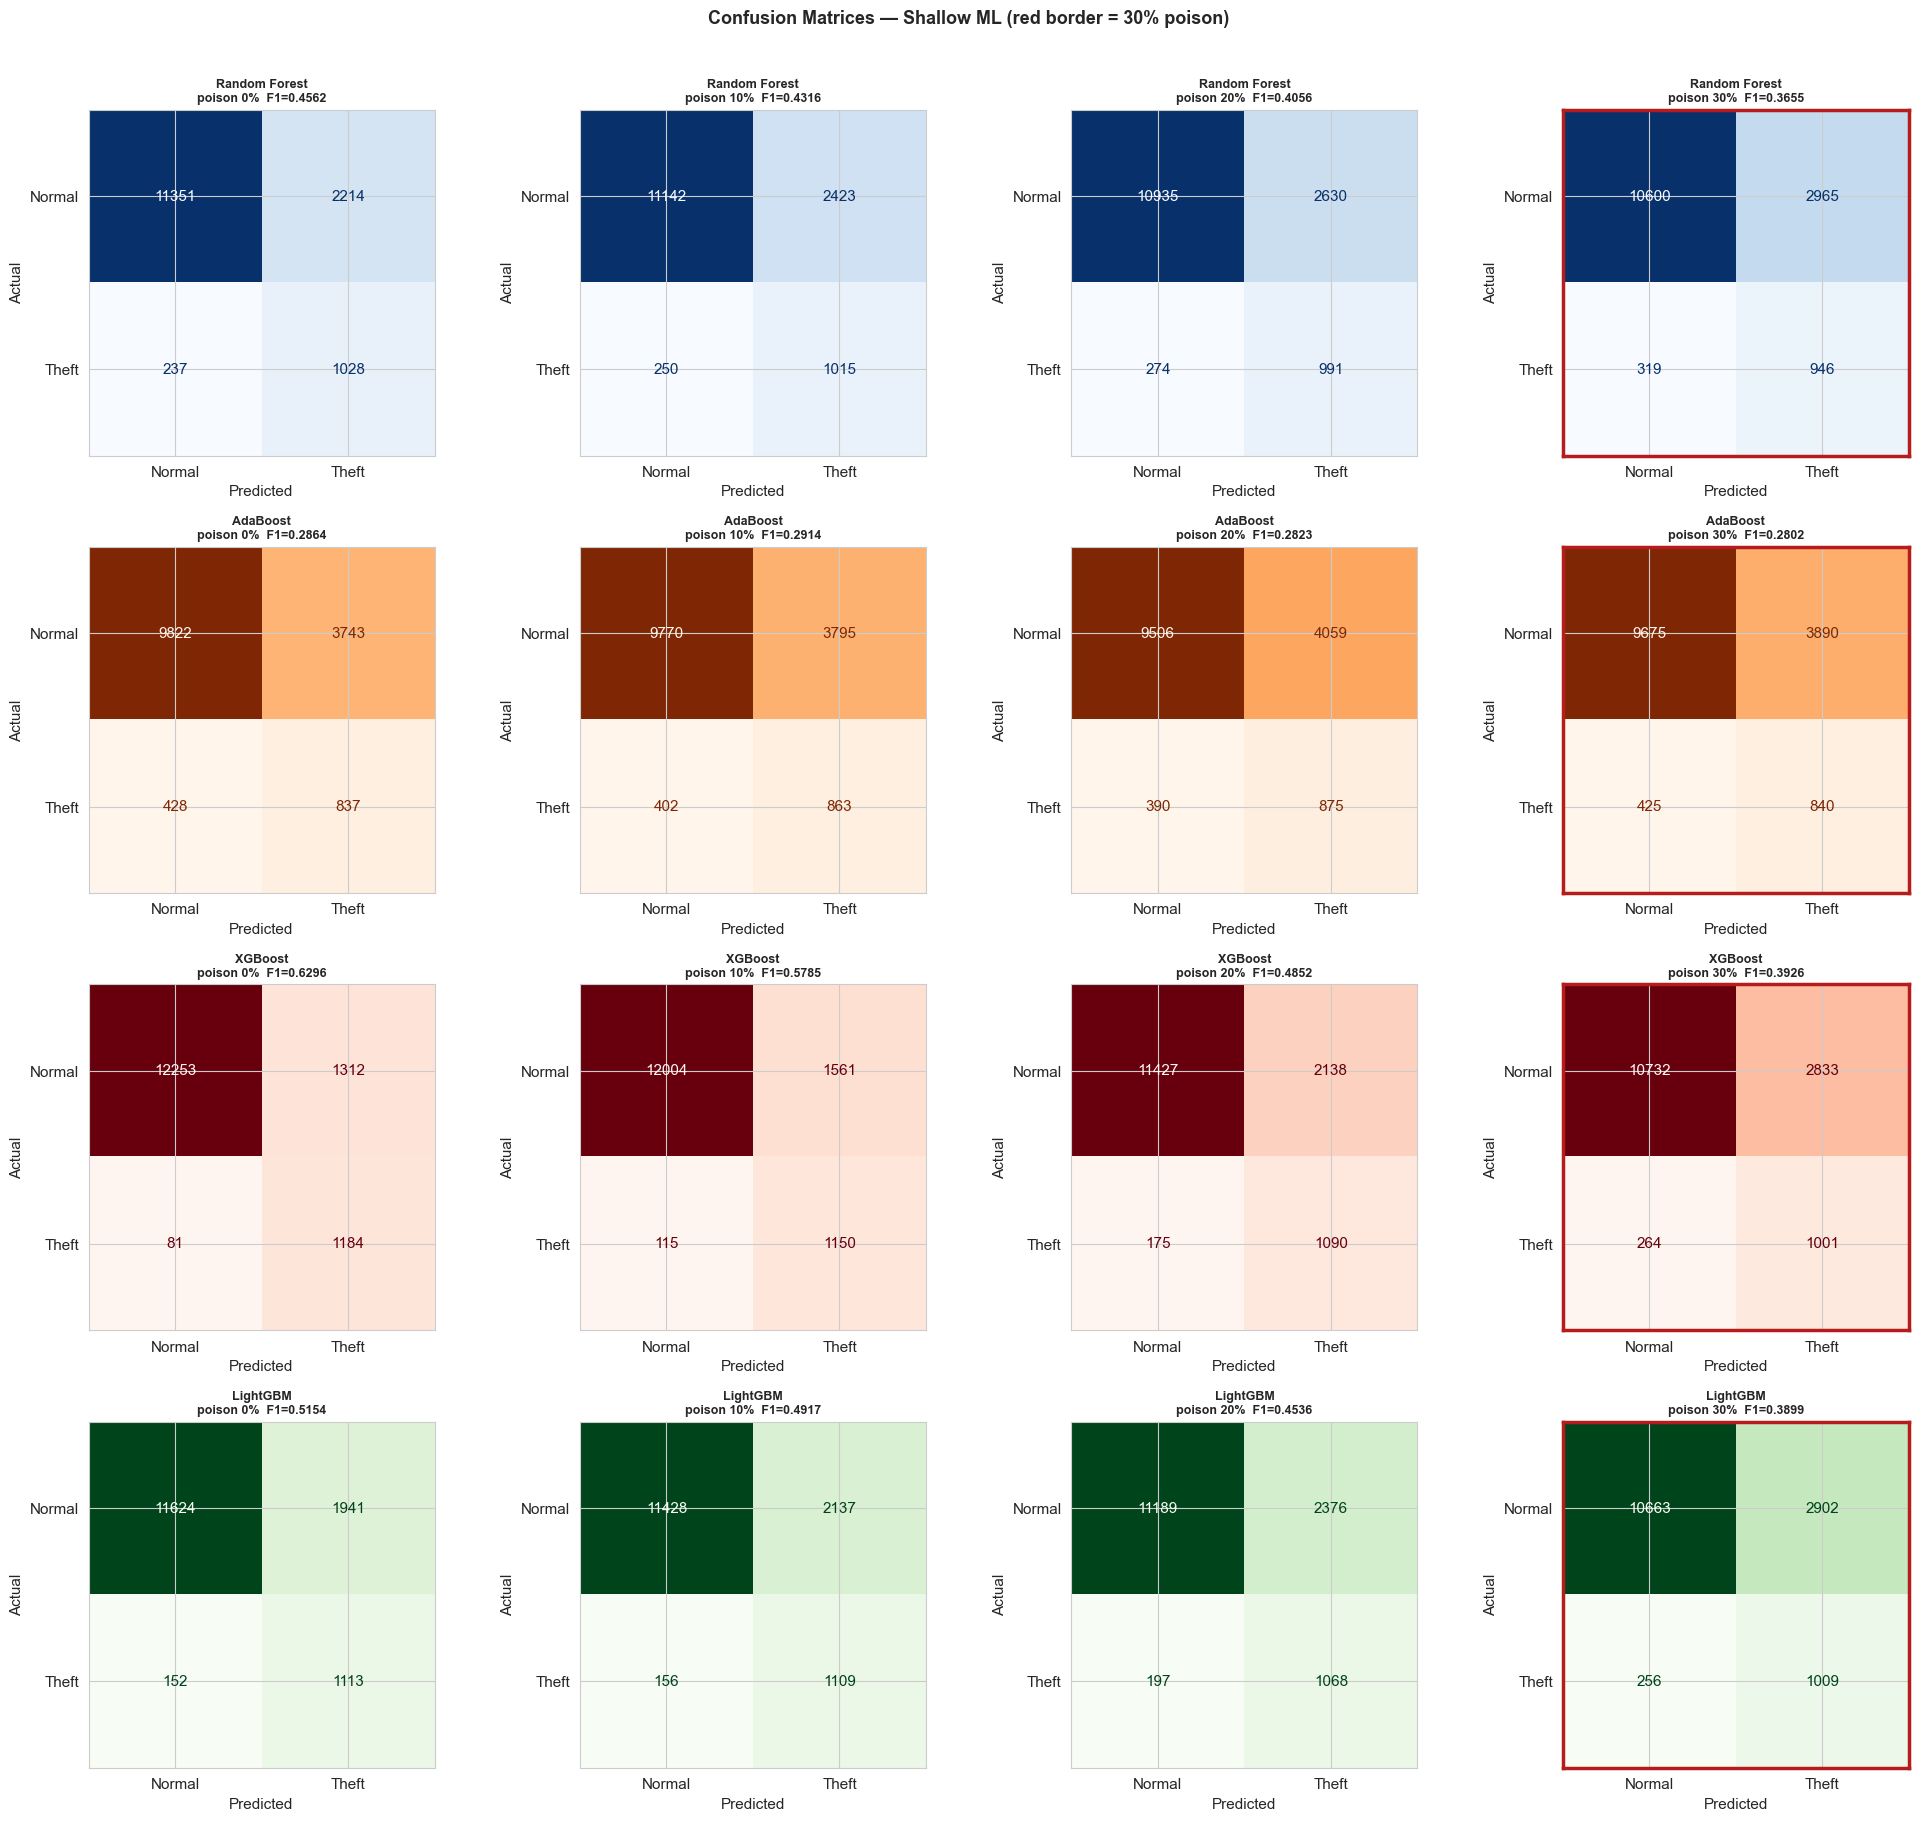

saved: week2_confusion_matrices.png


In [23]:
# ── Cell 10: Confusion Matrices — 4 models ────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(20, 18))
cmaps = ['Blues', 'Oranges', 'Reds', 'Greens']

for row, (model_name, cmap) in enumerate(zip(MODEL_COLORS.keys(), cmaps)):
    model_res = [r for r in all_results if r['Model'] == model_name]
    for col, r in enumerate(model_res):
        ax = axes[row][col]
        cm = confusion_matrix(y_test, r['y_pred'])
        ConfusionMatrixDisplay(cm, display_labels=['Normal','Theft']).plot(
            ax=ax, cmap=cmap, colorbar=False, values_format='d')
        ax.set_title(
            f'{model_name}\npoison {r["Poison_Rate"]}  F1={r["F1"]:.4f}',
            fontsize=9, fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        if r['Poison_Rate'] == '30%':
            for spine in ax.spines.values():
                spine.set_edgecolor('#B71C1C')
                spine.set_linewidth(2.5)

plt.suptitle('Confusion Matrices — Shallow ML (red border = 30% poison)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/sundar.g/Documents/projects folder/ElectricityTheftDetection/week2/week2_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: week2_confusion_matrices.png')

## 11. F1 Score and Delta Comparison

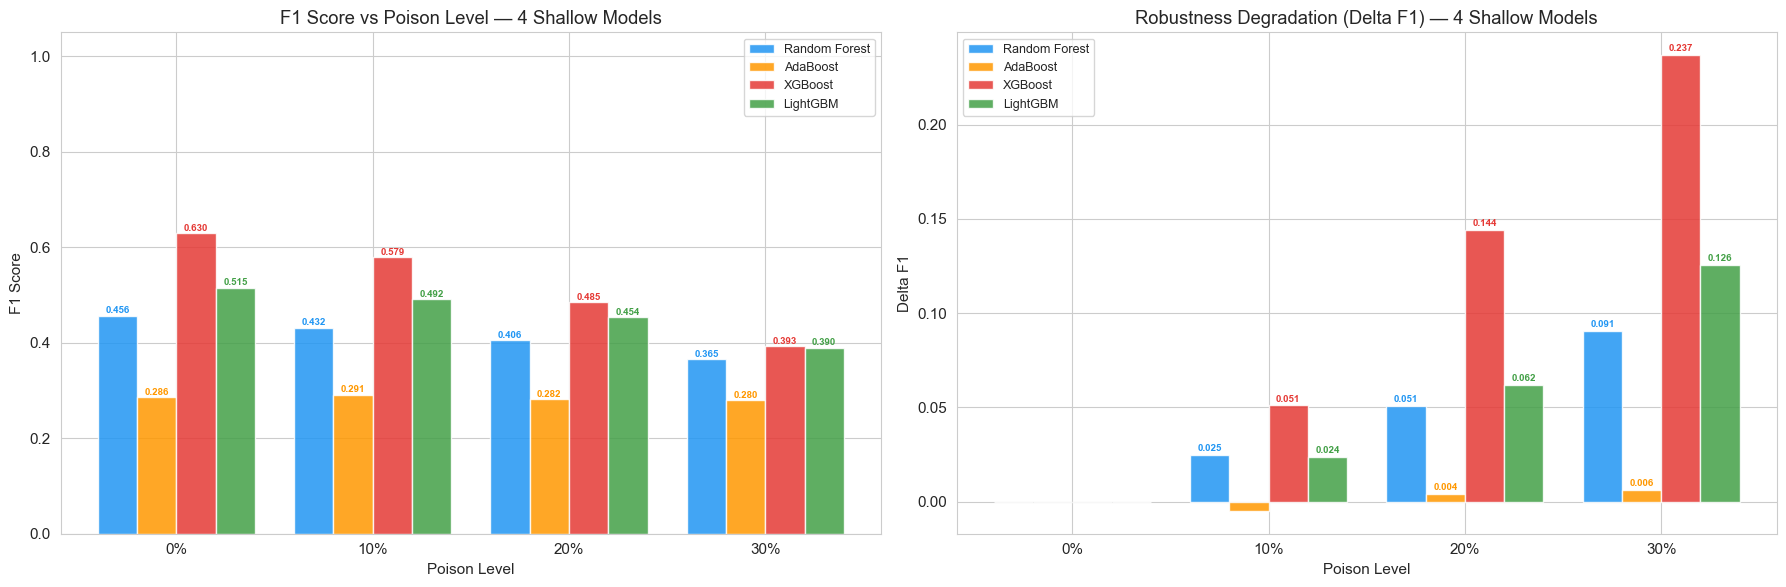

saved: week2_f1_delta.png


In [24]:
# ── Cell 11: F1 and Delta bar charts ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
x = np.arange(len(POISON_LABELS))
width = 0.20
offsets = [-0.30, -0.10, 0.10, 0.30]

for i, (mname, color) in enumerate(MODEL_COLORS.items()):
    scores = [r['F1'] for r in all_results if r['Model'] == mname]
    bars = axes[0].bar(x + offsets[i], scores, width, label=mname,
                       color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, scores):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', fontsize=7, fontweight='bold', color=color)

axes[0].set_xticks(x)
axes[0].set_xticklabels(POISON_LABELS)
axes[0].set_xlabel('Poison Level')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score vs Poison Level — 4 Shallow Models')
axes[0].legend(fontsize=9)
axes[0].set_ylim([0, 1.05])

for i, (mname, color) in enumerate(MODEL_COLORS.items()):
    m_res    = [r for r in all_results if r['Model'] == mname]
    clean_f1 = next(r['F1'] for r in m_res if r['Poison_Rate'] == '0%')
    deltas   = [round(clean_f1 - r['F1'], 4) for r in m_res]
    bars = axes[1].bar(x + offsets[i], deltas, width, label=mname,
                       color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, deltas):
        if val > 0.001:
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                         f'{val:.3f}', ha='center', fontsize=7, fontweight='bold', color=color)

axes[1].set_xticks(x)
axes[1].set_xticklabels(POISON_LABELS)
axes[1].set_xlabel('Poison Level')
axes[1].set_ylabel('Delta F1')
axes[1].set_title('Robustness Degradation (Delta F1) — 4 Shallow Models')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('/Users/sundar.g/Documents/projects folder/ElectricityTheftDetection/week2/week2_f1_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: week2_f1_delta.png')


## 12. AUC and Detection Rate Degradation

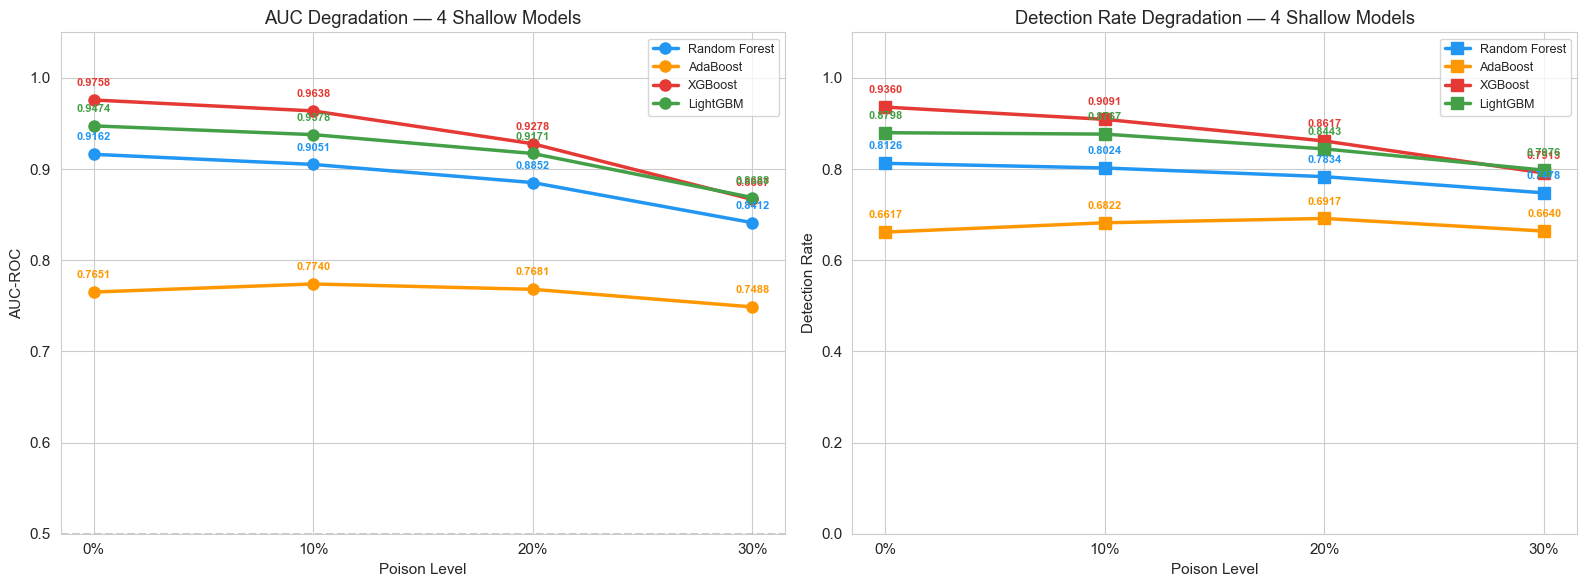

saved: week2_auc_dr.png


In [25]:
# ── Cell 12: AUC and DR line plots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for mname, color in MODEL_COLORS.items():
    m_res    = [r for r in all_results if r['Model'] == mname]
    auc_vals = [r['AUC'] for r in m_res]
    dr_vals  = [r['DR']  for r in m_res]

    axes[0].plot(POISON_LABELS, auc_vals, marker='o', linewidth=2.5,
                 markersize=8, color=color, label=mname)
    axes[1].plot(POISON_LABELS, dr_vals,  marker='s', linewidth=2.5,
                 markersize=8, color=color, label=mname)

    for i, (a, d) in enumerate(zip(auc_vals, dr_vals)):
        axes[0].annotate(f'{a:.4f}', xy=(i, a), xytext=(0, 10),
                         textcoords='offset points', ha='center',
                         fontsize=8, color=color, fontweight='bold')
        axes[1].annotate(f'{d:.4f}', xy=(i, d), xytext=(0, 10),
                         textcoords='offset points', ha='center',
                         fontsize=8, color=color, fontweight='bold')

axes[0].set_xlabel('Poison Level')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('AUC Degradation — 4 Shallow Models')
axes[0].legend(fontsize=9)
axes[0].set_ylim([0.5, 1.05])
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)

axes[1].set_xlabel('Poison Level')
axes[1].set_ylabel('Detection Rate')
axes[1].set_title('Detection Rate Degradation — 4 Shallow Models')
axes[1].legend(fontsize=9)
axes[1].set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig('/Users/sundar.g/Documents/projects folder/ElectricityTheftDetection/week2/week2_auc_dr.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: week2_auc_dr.png')

## 13. Summary

In [27]:
# ── Cell 13: Summary ──────────────────────────────────────────────────────────
cols = ['Model','Poison_Rate','DR','Precision','Recall',
        'F1','Accuracy','AUC','FPR','Train_Time_s']
results_df = pd.DataFrame([{k: v for k, v in r.items() if k in cols}
                            for r in all_results])[cols]

print(results_df.to_string(index=False))
results_df.to_csv('/Users/sundar.g/Documents/projects folder/ElectricityTheftDetection/week2/week2_results.csv', index=False)
print('\nsaved: processed_data/week2_results.csv')

print()
for mname in MODEL_COLORS.keys():
    m_res  = [r for r in all_results if r['Model'] == mname]
    clean  = next(r for r in m_res if r['Poison_Rate'] == '0%')
    worst  = next(r for r in m_res if r['Poison_Rate'] == '30%')
    print(f'{mname}')
    print(f'  clean — F1={clean["F1"]:.4f}  AUC={clean["AUC"]:.4f}  DR={clean["DR"]:.4f}')
    print(f'  @30%  — F1={worst["F1"]:.4f}  AUC={worst["AUC"]:.4f}  DR={worst["DR"]:.4f}')
    print(f'  delta — F1={clean["F1"]-worst["F1"]:+.4f}  '
          f'AUC={clean["AUC"]-worst["AUC"]:+.4f}  '
          f'DR={clean["DR"]-worst["DR"]:+.4f}')
    print()

        Model Poison_Rate     DR  Precision  Recall     F1  Accuracy    AUC    FPR  Train_Time_s
Random Forest          0% 0.8126     0.3171  0.8126 0.4562    0.8347 0.9162 0.1632          5.81
Random Forest         10% 0.8024     0.2952  0.8024 0.4316    0.8198 0.9051 0.1786          5.27
Random Forest         20% 0.7834     0.2737  0.7834 0.4056    0.8042 0.8852 0.1939          5.12
Random Forest         30% 0.7478     0.2419  0.7478 0.3655    0.7786 0.8412 0.2186          5.24
     AdaBoost          0% 0.6617     0.1828  0.6617 0.2864    0.7187 0.7651 0.2759         31.32
     AdaBoost         10% 0.6822     0.1853  0.6822 0.2914    0.7170 0.7740 0.2798         30.81
     AdaBoost         20% 0.6917     0.1773  0.6917 0.2823    0.7000 0.7681 0.2992         31.90
     AdaBoost         30% 0.6640     0.1776  0.6640 0.2802    0.7090 0.7488 0.2868         35.39
      XGBoost          0% 0.9360     0.4744  0.9360 0.6296    0.9061 0.9758 0.0967          0.99
      XGBoost         10% 0.90

In [28]:
import platform

print(platform.processor())
print(platform.machine())

try:
    import tensorflow as tf
    print('TF version:', tf.__version__)
    print('GPUs available:', tf.config.list_physical_devices('GPU'))
    print('Metal devices:', tf.config.list_physical_devices('GPU'))
except Exception as exc:
    print(f'TensorFlow diagnostics skipped: {exc.__class__.__name__}: {exc}')

arm
arm64
TF version: 2.15.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Metal devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# TensorFlow is optional for this notebook.
# The shallow ML pipeline does not depend on it, so this cell can be left as a note.
print('TensorFlow setup is optional for this notebook.')

Python 3.11.9
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.0/227.0 MB 3.7 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.3 MB/s eta 0:00:00
Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
Using cached gast-0.7.0-py3-none-any.whl (22 kB)
Using cached google_pasta-0.2.0-py3-none-any.whl (

In [30]:
# Uninstall conflicting versions
!pip3 uninstall tensorflow-macos tensorflow-metal numpy -y

# Install compatible versions
!pip3 install "numpy<2.0"
!pip3 install tensorflow-macos==2.13.0
!pip3    install tensorflow-metal==1.0.1

Found existing installation: tensorflow-macos 2.16.2
Uninstalling tensorflow-macos-2.16.2:
  Successfully uninstalled tensorflow-macos-2.16.2
Found existing installation: tensorflow-metal 1.2.0
Uninstalling tensorflow-metal-1.2.0:
  Successfully uninstalled tensorflow-metal-1.2.0
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
  Using cached typing_extensions-4.5.0-py3-none-any.whl.metadata (8.5 kB)
INFO: pip is looking at multiple versions of grpcio to determine which version is compatible with other requirements. This could take a while.
  Using cached google_auth_oauthlib-1.0.0-py2.py3-none-any.whl.metadata (2.7 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.w

In [32]:
i# Complete clean wipe
!pip3 uninstall tensorflow tensorflow-macos tensorflow-metal tensorflow-io-gcs-filesystem -y

# Check what numpy you have now
!python3 -c "import numpy; print(numpy.__version__)"

Found existing installation: tensorflow 2.16.2
Uninstalling tensorflow-2.16.2:
  Successfully uninstalled tensorflow-2.16.2
Found existing installation: tensorflow-macos 2.13.0
Uninstalling tensorflow-macos-2.13.0:
  Successfully uninstalled tensorflow-macos-2.13.0
Found existing installation: tensorflow-metal 1.0.1
Uninstalling tensorflow-metal-1.0.1:
  Successfully uninstalled tensorflow-metal-1.0.1
Found existing installation: tensorflow-io-gcs-filesystem 0.37.1
Uninstalling tensorflow-io-gcs-filesystem-0.37.1:
  Successfully uninstalled tensorflow-io-gcs-filesystem-0.37.1
1.24.3


In [33]:
# Install the correct combo for Python 3.11 Apple Silicon
!pip3 install "numpy<2.0" --force-reinstall
!pip3 install tensorflow==2.15.0
!pip3 install tensorflow-metal==1.1.0

  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
  Using cached tensorflow_io_gcs_filesystem-0.37.1-cp311-cp311-macosx_12_0_arm64.whl.metadata (14 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.8/208.8 MB 2.4 MB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 7.9 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 7.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 9.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 10.4 MB/s eta 0:00:0000:01
Using cached tensorflow_io_gcs_filesystem-0.37.1-cp31

In [ ]:
import tensorflow as tf
print("TF version :", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))
print("CPU devices:", tf.config.list_physical_devices('CPU'))

# Quick GPU test
import numpy as np
with tf.device('/GPU:0'):
    a = tf.constant(np.random.randn(1000, 1000), dtype=tf.float32)
    b = tf.matmul(a, a)
    print("GPU test   : passed —", b.shape)

: 

In [15]:
# ── ADASYN vs SMOTE Comparison ─────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE, ADASYN
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, confusion_matrix
import time

SEED = 42

print("Class distribution BEFORE balancing:")
print(f"  Normal (0): {(y_temp==0).sum():,}")
print(f"  Theft  (1): {(y_temp==1).sum():,}")
print(f"  Ratio      : {(y_temp==0).sum()/(y_temp==1).sum():.1f}:1")
print()

balancers = {
    'SMOTE':  SMOTE(random_state=SEED),
    'ADASYN': ADASYN(random_state=SEED)
}

comparison_results = []

for name, balancer in balancers.items():
    print(f"Running {name}...")

    X_bal, y_bal = balancer.fit_resample(X_temp, y_temp)

    print(f"  After balancing — Normal: {(y_bal==0).sum():,}  Theft: {(y_bal==1).sum():,}")

    pos_weight = (y_bal==0).sum() / (y_bal==1).sum()
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=pos_weight,
        random_state=SEED,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    )

    t0 = time.time()
    model.fit(X_bal, y_bal)
    elapsed = time.time() - t0

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()



    result = {
        'Method'    : name,
        'Train_Size': len(y_bal),
        'Normal'    : int((y_bal==0).sum()),
        'Theft'     : int((y_bal==1).sum()),
        'F1'        : round(f1_score(y_test, y_pred), 4),
        'DR'        : round(recall_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'AUC'       : round(roc_auc_score(y_test, y_proba), 4),
        'FPR'       : round(fp / (fp + tn), 4),
        'Time_s'    : round(elapsed, 2)
    }
    comparison_results.append(result)

    print(f"  F1={result['F1']}  DR={result['DR']}  "
          f"Precision={result['Precision']}  AUC={result['AUC']}  FPR={result['FPR']}")
    print()

# ── Print comparison table ─────────────────────────────────────────────────────
print("=" * 70)
print("  SMOTE vs ADASYN — XGBoost on Clean Data (0% poison)")
print("=" * 70)
print(f"{'Method':<10} {'Train':<8} {'Normal':<8} {'Theft':<8} "
      f"{'F1':<8} {'DR':<8} {'Precision':<10} {'AUC':<8} {'FPR':<8}")
print("-" * 70)
for r in comparison_results:
    print(f"{r['Method']:<10} {r['Train_Size']:<8} {r['Normal']:<8} "
          f"{r['Theft']:<8} {r['F1']:<8} {r['DR']:<8} "
          f"{r['Precision']:<10} {r['AUC']:<8} {r['FPR']:<8}")
print("=" * 70)

Class distribution BEFORE balancing:
  Normal (0): 27,130
  Theft  (1): 2,530
  Ratio      : 10.7:1

Running SMOTE...
  After balancing — Normal: 27,130  Theft: 27,130
  F1=0.6296  DR=0.936  Precision=0.4744  AUC=0.9758  FPR=0.0967

Running ADASYN...
  After balancing — Normal: 27,130  Theft: 27,223
  F1=0.596  DR=0.9423  Precision=0.4358  AUC=0.9767  FPR=0.1137

  SMOTE vs ADASYN — XGBoost on Clean Data (0% poison)
Method     Train    Normal   Theft    F1       DR       Precision  AUC      FPR     
----------------------------------------------------------------------
SMOTE      54260    27130    27130    0.6296   0.936    0.4744     0.9758   0.0967  
ADASYN     54353    27130    27223    0.596    0.9423   0.4358     0.9767   0.1137  


In [14]:
print(X_temp.shape)
print(y_temp.shape)

(29660, 42)
(29660,)


In [29]:
print(len(all_results))

16


In [30]:
import os
print(os.path.exists('/Users/sundar.g/Documents/projects folder/ElectricityTheftDetection/processed_data/week2_results.csv'))

True
